<>:63: SyntaxWarning: invalid escape sequence '\s'
<>:63: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_42349/2254844544.py:63: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('Stress $\sigma_a$, ksi')


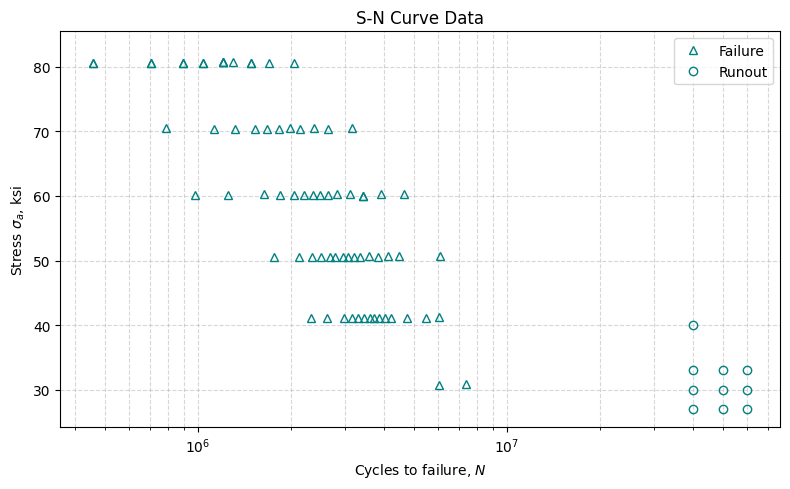

Accuracy Score: 1.0000



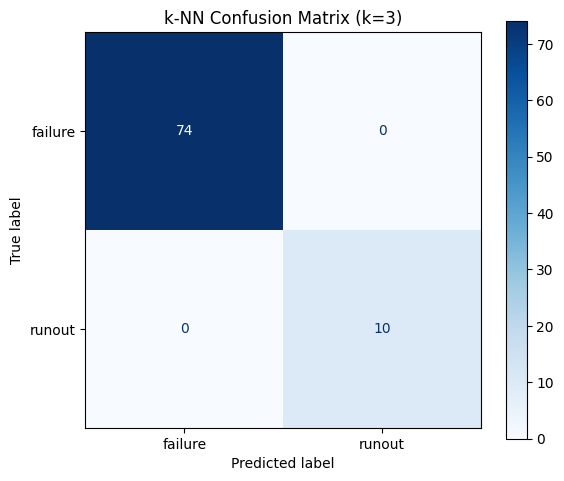

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# ==========================================
# 1. DATA PREPARATION
# ==========================================

# Load existing digitized data
df = pd.read_csv('plot-data.csv')

# Clean up column names (removes the space in ' y')
df.columns = df.columns.str.strip()

# Label your digitized points as 'failure'
df['label'] = 'failure'

# Manually define the runout points estimated from the image
runout_data = {
    'x': [
        4.0e7,               # y = 40
        4.0e7, 5.0e7, 6.0e7, # y = 33
        4.0e7, 5.0e7, 6.0e7, # y = 30
        4.0e7, 5.0e7, 6.0e7  # y = 27
    ],
    'y': [
        40.0, 
        33.0, 33.0, 33.0, 
        30.0, 30.0, 30.0, 
        27.0, 27.0, 27.0
    ],
    'label': ['runout'] * 10
}
df_runout = pd.DataFrame(runout_data)

# Combine both datasets
df_combined = pd.concat([df, df_runout], ignore_index=True)


# ==========================================
# 2. PLOT THE S-N CURVE
# ==========================================

plt.figure(figsize=(8, 5))

# Filter subsets for plotting different markers
failures = df_combined[df_combined['label'] == 'failure']
runouts = df_combined[df_combined['label'] == 'runout']

# Plot failures (matching the reference triangles)
plt.plot(failures['x'], failures['y'], marker='^', linestyle='', 
         color='none', markeredgecolor='teal', label='Failure')

# Plot runouts (matching the reference circles)
plt.plot(runouts['x'], runouts['y'], marker='o', linestyle='', 
         color='none', markeredgecolor='teal', label='Runout')

# Add styling and log scale
plt.xscale('log')
plt.title('S-N Curve Data')
plt.xlabel('Cycles to failure, $N$')
plt.ylabel('Stress $\sigma_a$, ksi')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


# ==========================================
# 3. k-NN CLASSIFIER & EVALUATION
# ==========================================

# Prepare features (X) and labels (y)
X = df_combined[['x', 'y']] 
y = df_combined['label']     

# Train the k-NN classifier (3 neighbors, Euclidean distance)
knn = KNeighborsClassifier(n_neighbors=3, metric='euclidean')
knn.fit(X, y)

# Calculate Accuracy
predictions = knn.predict(X)
accuracy = accuracy_score(y, predictions)
print(f"Accuracy Score: {accuracy:.4f}\n")

# Calculate and Plot Confusion Matrix
cm = confusion_matrix(y, predictions, labels=knn.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn.classes_)

# Plotting the Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("k-NN Confusion Matrix (k=3)")
plt.tight_layout()
plt.show()